In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv ("C:/Users/Coder/Downloads/youtoxic_english_1000.csv")
df.head()

,CommentId,VideoId,Text,IsToxic,IsAbusive,IsThreat,IsProvocative,IsObscene,IsHatespeech,IsRacist,IsNationalist,IsSexist,IsHomophobic,IsReligiousHate,IsRadicalism
0,Ugg2KwwX0V8-aXgCoAEC,04kJtp6pVXI,If only people would just take a step back and...,False,False,False,False,False,False,False,False,False,False,False,False
1,Ugg2s5AzSPioEXgCoAEC,04kJtp6pVXI,Law enforcement is not trained to shoot to app...,True,True,False,False,False,False,False,False,False,False,False,False
2,Ugg3dWTOxryFfHgCoAEC,04kJtp6pVXI,\nDont you reckon them 'black lives matter' ba...,True,True,False,False,True,False,False,False,False,False,False,False
3,Ugg7Gd006w1MPngCoAEC,04kJtp6pVXI,There are a very large number of people who do...,False,False,False,False,False,False,False,False,False,False,False,False
4,Ugg8FfTbbNF8IngCoAEC,04kJtp6pVXI,"The Arab dude is absolutely right, he should h...",False,False,False,False,False,False,False,False,False,False,False,False


In [5]:
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())

(1000, 15)
CommentId           str
VideoId             str
Text                str
IsToxic            bool
IsAbusive          bool
IsThreat           bool
IsProvocative      bool
IsObscene          bool
IsHatespeech       bool
IsRacist           bool
IsNationalist      bool
IsSexist           bool
IsHomophobic       bool
IsReligiousHate    bool
IsRadicalism       bool
dtype: object
CommentId          0
VideoId            0
Text               0
IsToxic            0
IsAbusive          0
IsThreat           0
IsProvocative      0
IsObscene          0
IsHatespeech       0
IsRacist           0
IsNationalist      0
IsSexist           0
IsHomophobic       0
IsReligiousHate    0
IsRadicalism       0
dtype: int64


IsToxic
False    538
True     462
Name: count, dtype: int64


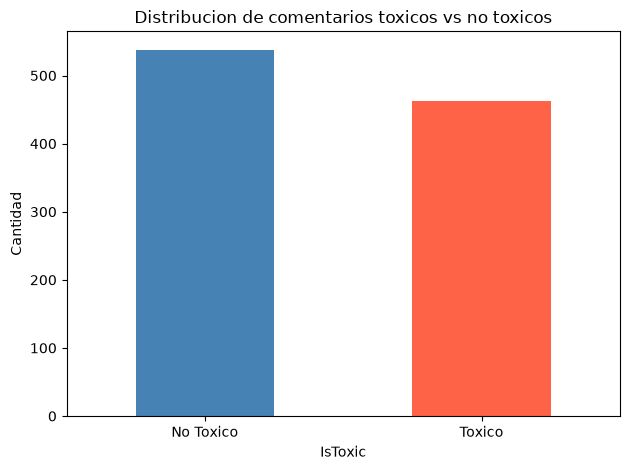

In [8]:
counts = df["IsToxic"].value_counts()
print(counts)

counts.plot(kind="bar", color=["steelblue", "tomato"])
plt.xticks([0, 1], ["No Toxico", "Toxico"], rotation=0)
plt.title("Distribucion de comentarios toxicos vs no toxicos")
plt.ylabel("Cantidad")
plt.tight_layout()
plt.show()


IsAbusive          353
IsProvocative      161
IsHatespeech       138
IsRacist           125
IsObscene          100
IsThreat            21
IsReligiousHate     12
IsNationalist        8
IsSexist             1
IsHomophobic         0
IsRadicalism         0
dtype: int64


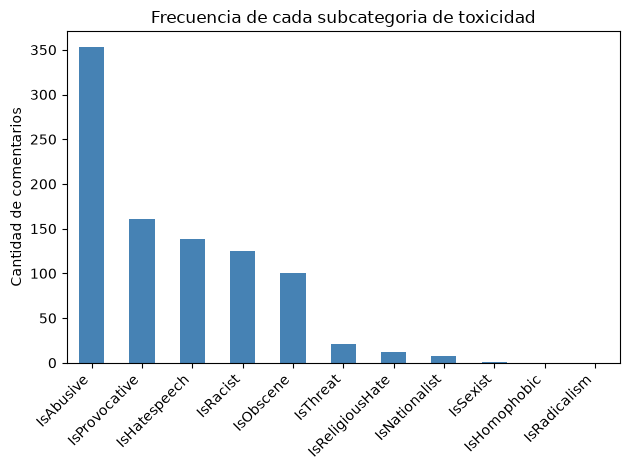

In [10]:
subcats = ["IsAbusive", "IsThreat", "IsProvocative", "IsObscene",
           "IsHatespeech", "IsRacist", "IsNationalist", "IsSexist",
           "IsHomophobic", "IsReligiousHate", "IsRadicalism"]

subcat_counts = df[subcats].sum().sort_values(ascending=False)
print(subcat_counts)

subcat_counts.plot(kind="bar", color="steelblue")
plt.title("Frecuencia de cada subcategoria de toxicidad")
plt.ylabel("Cantidad de comentarios")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

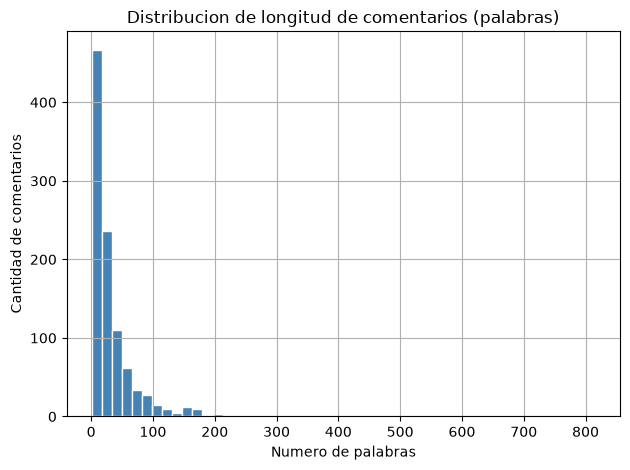

count    1000.000000
mean       33.776000
std        49.069498
min         1.000000
25%         9.000000
50%        19.000000
75%        39.000000
max       815.000000
Name: word_count, dtype: float64


In [14]:
df["word_count"] = df["Text"].str.split().str.len()

df["word_count"].hist(bins=50, color="steelblue", edgecolor="white")
plt.title("Distribucion de longitud de comentarios (palabras)")
plt.xlabel("Numero de palabras")
plt.ylabel("Cantidad de comentarios")
plt.tight_layout()
plt.show()

print(df["word_count"].describe())


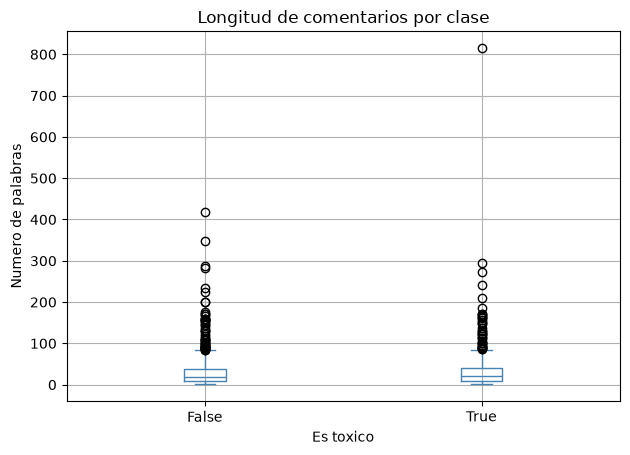

IsToxic
False    33.065056
True     34.603896
Name: word_count, dtype: float64


In [20]:
df.boxplot(column="word_count", by="IsToxic", color="steelblue")
plt.title("Longitud de comentarios por clase")
plt.suptitle("")
plt.xlabel("Es toxico")
plt.ylabel("Numero de palabras")
plt.tight_layout()
plt.show()

print(df.groupby("IsToxic")["word_count"].mean())

people     222
black      218
police     156
like       147
get        143
white      128
would      118
brown       90
officer     75
one         75
shot        73
cop         66
know        64
cops        59
guy         55
video       55
need        51
fuck        51
blacks      50
man         47
Name: count, dtype: int64


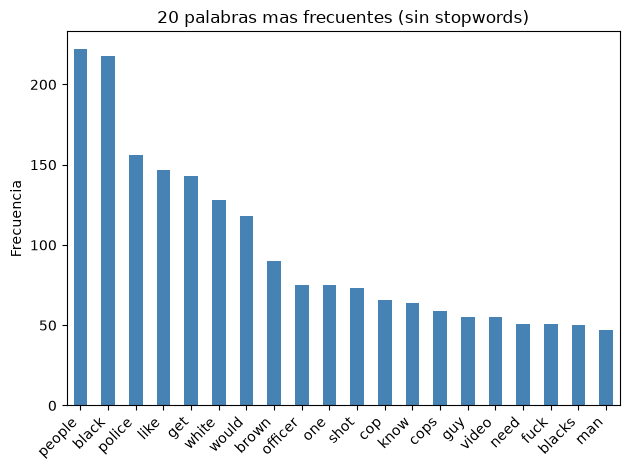

In [23]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

all_words = " ".join(df["Text"].str.lower()).split()
filtered_words = [w for w in all_words if w not in stop_words and len(w) > 2]

freq = pd.Series(filtered_words).value_counts().head(20)
print(freq)

freq.plot(kind="bar", color="steelblue")
plt.title("20 palabras mas frecuentes (sin stopwords)")
plt.ylabel("Frecuencia")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

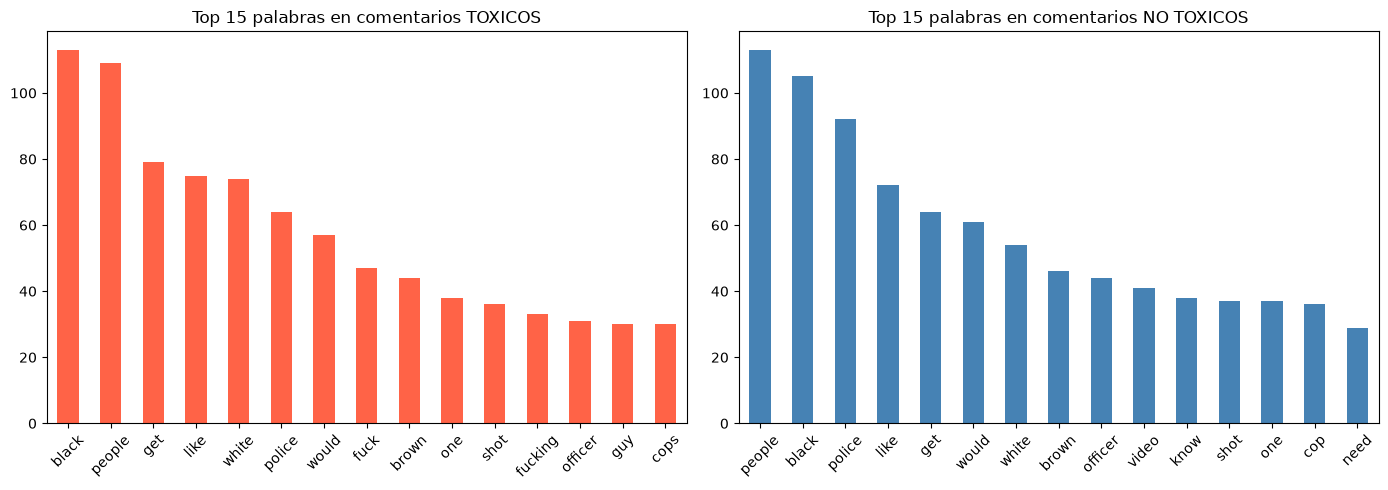

In [24]:
toxic_words = " ".join(df[df["IsToxic"] == True]["Text"].str.lower()).split()
clean_words = " ".join(df[df["IsToxic"] == False]["Text"].str.lower()).split()

toxic_filtered = [w for w in toxic_words if w not in stop_words and len(w) > 2]
clean_filtered = [w for w in clean_words if w not in stop_words and len(w) > 2]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pd.Series(toxic_filtered).value_counts().head(15).plot(kind="bar", ax=axes[0], color="tomato")
axes[0].set_title("Top 15 palabras en comentarios TOXICOS")
axes[0].tick_params(axis="x", rotation=45)

pd.Series(clean_filtered).value_counts().head(15).plot(kind="bar", ax=axes[1], color="steelblue")
axes[1].set_title("Top 15 palabras en comentarios NO TOXICOS")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


In [25]:
import os

df["clean_text"] = df["Text"].str.lower()
df["IsToxic"] = df["IsToxic"].astype(int)

os.makedirs("../data/processed", exist_ok=True)
df.to_csv("../data/processed/youtoxic_clean.csv", index=False)

print("Guardado correctamente")
print(df[["Text", "clean_text", "IsToxic"]].head(3))


Guardado correctamente
                                                Text  \
0  If only people would just take a step back and...   
1  Law enforcement is not trained to shoot to app...   
2  \nDont you reckon them 'black lives matter' ba...   

                                          clean_text  IsToxic  
0  if only people would just take a step back and...        0  
1  law enforcement is not trained to shoot to app...        1  
2  \ndont you reckon them 'black lives matter' ba...        1  
